# Lab 2: Classification Using KNN and RNN Algorithms

**Name:** Anusha Pittala  
**Course:** Advanced Big Data and Data Mining (MSCS-634-M50)  
**Semester:** Fall 2026  
**Assignment:** Lab 2 - Classification Using KNN and RNN Algorithms

## Step 1: Load and Prepare the Dataset

The Wine dataset from the sklearn library is used for this classification experiment. The dataset contains 178 samples, 13 numerical features, and three wine classes. Basic exploration is performed to review the dataset structure, feature information, and class distribution.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

In [4]:
wine = load_wine()

X = wine.data
y = wine.target

print("Feature Names:")
print(wine.feature_names)

print("\nTarget Names:")
print(wine.target_names)

print("\nDataset Shape:")
print(X.shape)

Feature Names:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Target Names:
['class_0' 'class_1' 'class_2']

Dataset Shape:
(178, 13)


In [5]:
df = pd.DataFrame(X, columns=wine.feature_names)

df['target'] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [6]:
print("Dataset Information:")
df.info()

print("\nClass Distribution:")
print(df['target'].value_counts())

print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null 

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


### Train-Test Split

The dataset is divided into 80% training data and 20% testing data. A random state of 42 is used for reproducibility, and stratification is applied to maintain the class distribution in both sets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)

Training Set Size: (142, 13)
Testing Set Size: (36, 13)


## K-Nearest Neighbors (KNN)

The K-Nearest Neighbors classifier was evaluated using different values of k: 1, 5, 11, 15, and 21. The accuracy of each model was recorded to determine how the number of neighbors affects classification performance.

In [8]:
k_values = [1, 5, 11, 15, 21]

knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    knn_accuracies.append(accuracy)
    
    print(f"k = {k}, Accuracy = {accuracy:.4f}")

k = 1, Accuracy = 0.7778
k = 5, Accuracy = 0.8056
k = 11, Accuracy = 0.8056
k = 15, Accuracy = 0.8056
k = 21, Accuracy = 0.8056


In [9]:
knn_results = pd.DataFrame({
    'K Value': k_values,
    'Accuracy': knn_accuracies
})

knn_results

,K Value,Accuracy
0,1,0.777778
1,5,0.805556
2,11,0.805556
3,15,0.805556
4,21,0.805556


### KNN Observation

The highest KNN accuracy was approximately 80.56%, achieved with k values of 5, 11, 15, and 21. The model with k = 1 achieved a slightly lower accuracy of approximately 77.78%. This indicates that using multiple neighbors provided more stable classification performance for this dataset.

## Radius Neighbors Classifier (RNN)

The Radius Neighbors classifier was evaluated using radius values of 350, 400, 450, 500, 550, and 600. The accuracy for each radius was recorded to study the effect of neighborhood radius on classification performance.


In [10]:
radius_values = [350, 400, 450, 500, 550, 600]

rnn_accuracies = []

for radius in radius_values:
    
    rnn = RadiusNeighborsClassifier(
        radius=radius,
        outlier_label='most_frequent'
    )
    
    rnn.fit(X_train, y_train)
    
    y_pred = rnn.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    
    rnn_accuracies.append(accuracy)
    
    print(f"Radius = {radius}, Accuracy = {accuracy:.4f}")

Radius = 350, Accuracy = 0.7222
Radius = 400, Accuracy = 0.6944
Radius = 450, Accuracy = 0.6944
Radius = 500, Accuracy = 0.6944
Radius = 550, Accuracy = 0.6667
Radius = 600, Accuracy = 0.6667


In [11]:
rnn_results = pd.DataFrame({
    'Radius': radius_values,
    'Accuracy': rnn_accuracies
})

rnn_results

,Radius,Accuracy
0,350,0.722222
1,400,0.694444
2,450,0.694444
3,500,0.694444
4,550,0.666667
5,600,0.666667


### RNN Observation

The Radius Neighbors classifier achieved its highest accuracy of approximately 72.22% at a radius of 350. Accuracy decreased as the radius increased, reaching approximately 66.67% for radius values of 550 and 600. This suggests that including observations from a wider neighborhood reduced classification performance for this dataset.

## KNN Accuracy Visualization

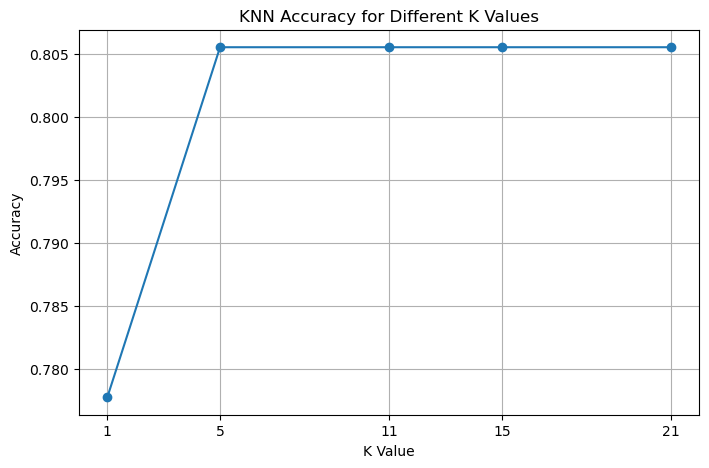

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    knn_accuracies,
    marker='o'
)

plt.title('KNN Accuracy for Different K Values')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)

plt.show()

## RNN Accuracy Visualization

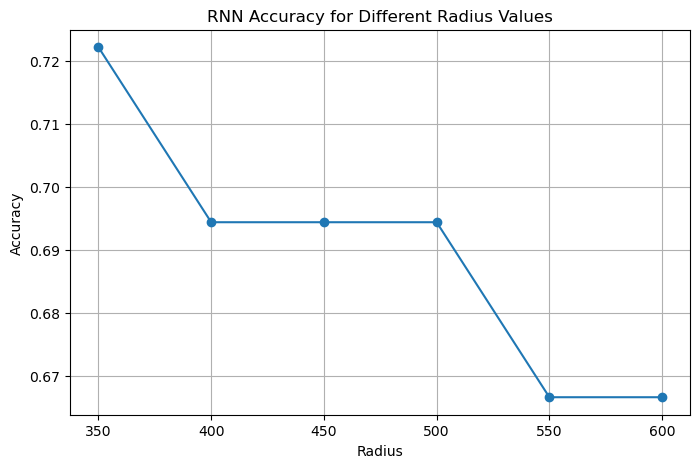

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    radius_values,
    rnn_accuracies,
    marker='o'
)

plt.title('RNN Accuracy for Different Radius Values')
plt.xlabel('Radius')
plt.ylabel('Accuracy')
plt.xticks(radius_values)
plt.grid(True)

plt.show()

## Results and Observations

The KNN classifier produced better classification accuracy than the Radius Neighbors classifier for the tested parameter values.

For KNN, the model using k = 1 produced slightly lower accuracy, while k values of 5, 11, 15, and 21 produced similar and higher accuracy. This shows that using more than one neighboring sample helped provide more stable predictions.

For the Radius Neighbors classifier, the radius of 350 produced the highest accuracy among the tested radius values. As the radius increased, the accuracy generally decreased. A larger radius may include observations from different wine classes, which can negatively affect classification.

Based on these results, KNN performed better for this dataset and parameter configuration.

## KNN vs RNN

KNN determines the class of a sample using a fixed number of nearest neighbors. It can be useful when the data points have relatively consistent density because each prediction considers the same number of nearby samples.

Radius Neighbors uses every training sample located within a specified distance from the test sample. It may be useful when the density of data varies because different observations can have different numbers of neighbors.

For this experiment, KNN was preferable because it achieved higher accuracy than RNN for the tested parameter values. However, the effectiveness of either method depends on the dataset and the parameters selected.